<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; font-family: 'Segoe UI', Arial, sans-serif; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.2em; margin: 0 0 8px 0; font-weight: 700; letter-spacing: 1px;">
    Práctica de Deep Learning
  </h1>
  <h2 style="font-size: 1.4em; margin: 0 0 24px 0; font-weight: 300; color: #a8d8ea;">
    Parte II — Predicción de Series Temporales con Transformers
  </h2>
  <table style="border-collapse: collapse; width: 100%; font-size: 0.95em;">
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Asignatura</td>
      <td style="padding: 6px 0;">Aprendizaje Automático II</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Tareas</td>
      <td style="padding: 6px 0;">Seno sintético · Acciones AAPL (yfinance)</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Framework</td>
      <td style="padding: 6px 0;">PyTorch — nn.TransformerEncoder</td>
    </tr>
  </table>
  <hr style="border: none; border-top: 1px solid #a8d8ea44; margin: 20px 0 10px 0;">
  <p style="margin: 0; font-size: 0.8em; color: #a8d8ea88;">Universidad Politécnica de Madrid · Aprendizaje Automático II</p>
</div>

## Descripción general

Los **Transformers** fueron diseñados originalmente para procesar secuencias de texto (NLP), pero su mecanismo de **atención multi-cabeza** los hace igualmente poderosos para series temporales: en lugar de palabras, la secuencia son valores numéricos ordenados en el tiempo.

### Ventaja frente a RNNs/LSTMs

| Aspecto | RNN / LSTM | Transformer |
|---|---|---|
| Dependencias largas | Difícil (gradiente que desvanece) | Directas vía atención |
| Paralelización | Secuencial | Total (entrenamiento rápido) |
| Interpretabilidad | Opaca | Pesos de atención visibles |

### Tareas de esta práctica

| # | Tarea | Datos | Predicción |
|---|---|---|---|
| 1 | Función seno sintética | 1 000 puntos generados | 200 valores futuros |
| 2 | Precio diario AAPL | Yahoo Finance 2020–2026 | 50 días futuros |

### Arquitectura general

```
Entrada  [batch, seq_len, 1]
   │
   ▼
Linear (input_projection)   ← proyecta 1 → d_model
   │
   ▼
TransformerEncoder           ← N capas de self-attention + FFN
   │
   ▼
Último token  [:, -1, :]    ← estado del instante más reciente
   │
   ▼
Linear (output_layer)        ← predice el siguiente valor escalar
   │
   ▼
Salida  [batch, 1]
```

> **Nota:** Se usa solo el **Encoder** (sin Decoder). El modelo aprende a comprimir toda la ventana de contexto en el último token y a partir de él predecir el siguiente paso.

## 1. Predicción de Función Seno

La función seno es el banco de pruebas ideal para un modelo de series temporales: es **periódica, suave y determinista**. Si el Transformer no consigue aprender el patrón del seno, no tiene sentido pasarle datos reales de bolsa.

### 1.1 Generación de datos y ventanas deslizantes

Se generan 1 000 puntos de `sin(t)` con `t ∈ [0, 100]`. Luego se construyen pares `(X, y)` mediante una **ventana deslizante** de tamaño `seq_length = 50`:

```
t:  [0,  1,  2, ... 49]  → predice t[50]
t:  [1,  2,  3, ... 50]  → predice t[51]
    ...
```

Esto transforma la serie en un problema de regresión supervisado estándar. El resultado son tensores de forma `X: [950, 50, 1]` e `y: [950, 1]`.

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la onda seno
t = np.linspace(0, 100, 1000) # 1000 puntos de 0 a 100
data = np.sin(t).reshape(-1, 1)

# 2. Función para crear ventanas (Secuencias)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50 
X, y = create_sequences(data, seq_length)

# Convertir a Tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

cuda


### 1.2 Arquitectura — `SequenceTransformer` con Positional Encoding

#### Hiperparámetros

| Parámetro | Valor | Descripción |
|---|---|---|
| `d_model` | 32 | Dimensión del espacio de embeddings |
| `nhead` | 4 | Cabezas de atención (32 / 4 = 8 dim/cabeza) |
| `num_layers` | 2 | Capas apiladas del Encoder |
| `seq_length` | 50 | Contexto de entrada (50 pasos anteriores) |
| `dropout (PE)` | 0.0 | Sin dropout en PE — señal limpia y determinista |

#### ¿Por qué Positional Encoding en el seno si ya funciona sin él?

El self-attention es **permutation-invariant**: sin PE el modelo no sabe si `sin(t=5)` ocurre antes o después de `sin(t=10)`. Para el seno esto es menos crítico que para precios bursátiles porque la señal es periódica y los valores **implican** cierta posición temporal.

Sin embargo, añadir PE tiene dos ventajas reales:

1. **Predicción autorregresiva más robusta**: al generar los 200 pasos futuros, el modelo sabe en qué posición de la ventana está cada token, lo que ayuda a mantener la fase del seno durante más pasos antes de que el error se acumule.

2. **Coherencia arquitectónica**: ambos modelos (seno y AAPL) usan la misma clase `PositionalEncoding`. Esto permite comparar resultados sin que las diferencias de arquitectura sean un factor de confusión.

> Se usa `dropout=0.0` (vs `0.1` en AAPL) porque la señal seno es determinista y no necesita regularización adicional.

In [18]:
import math

class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal (Vaswani et al., 2017).
    Inyecta información de posición temporal en los embeddings.

        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Los pesos son fijos (register_buffer) — no se entrenan.
    """
    def __init__(self, d_model, max_len=500, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class SequenceTransformer(nn.Module):
    """
    Transformer ligero para predicción de la función seno.
    Usa dropout=0.0 en el PE — señal determinista, sin necesidad de regularización.
    """
    def __init__(self, d_model=32, nhead=4):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoding     = PositionalEncoding(d_model, dropout=0.0)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):          # x: [batch, seq_len, 1]
        x = self.input_projection(x)   # [batch, seq_len, d_model]
        x = self.pos_encoding(x)       # + codificación posicional
        x = self.transformer(x)        # [batch, seq_len, d_model]
        x = x[:, -1, :]               # último token [batch, d_model]
        return self.output_layer(x)    # [batch, 1]

model     = SequenceTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(model)
print(f"\nParámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SequenceTransformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

Parámetros entrenables: 275,105


### 1.3 Entrenamiento

Se entrena con **batch completo** (todos los 950 ejemplos a la vez) durante 100 épocas. La función de pérdida es el **Error Cuadrático Medio (MSE)** entre el valor predicho y el real:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

El optimizador **Adam** con `lr = 0.001` ajusta los pesos de forma adaptativa. Al tratarse de un seno, la pérdida debería descender por debajo de `1e-4` rápidamente.

In [19]:
epochs = 100

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X)          # Forward pass
    loss = criterion(output, y)
    loss.backward()            # Backpropagation
    optimizer.step()           # Actualizar pesos

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}  |  Loss: {loss.item():.6f}")

Epoch 10/100  |  Loss: 0.048080
Epoch 20/100  |  Loss: 0.020476
Epoch 30/100  |  Loss: 0.016263
Epoch 40/100  |  Loss: 0.010983
Epoch 50/100  |  Loss: 0.009389
Epoch 60/100  |  Loss: 0.007004
Epoch 70/100  |  Loss: 0.006510
Epoch 80/100  |  Loss: 0.006320
Epoch 90/100  |  Loss: 0.004998
Epoch 100/100  |  Loss: 0.005031


### 1.4 Predicción Autorregresiva

Una vez entrenado, el modelo genera los valores futuros de forma **autorregresiva**: cada predicción se convierte en la entrada del siguiente paso. La ventana se desplaza hacia adelante en cada iteración:

```
Ventana inicial:  [t₋₄₉, t₋₄₈, ..., t₀]  → predice  t₁
Ventana siguiente: [t₋₄₈, t₋₄₇, ..., t₁]  → predice  t₂
...
```

> **Importante:** El error se acumula con cada paso. Para el seno (función periódica y determinista) esto funciona bien; para datos reales la incertidumbre crece con el horizonte de predicción.

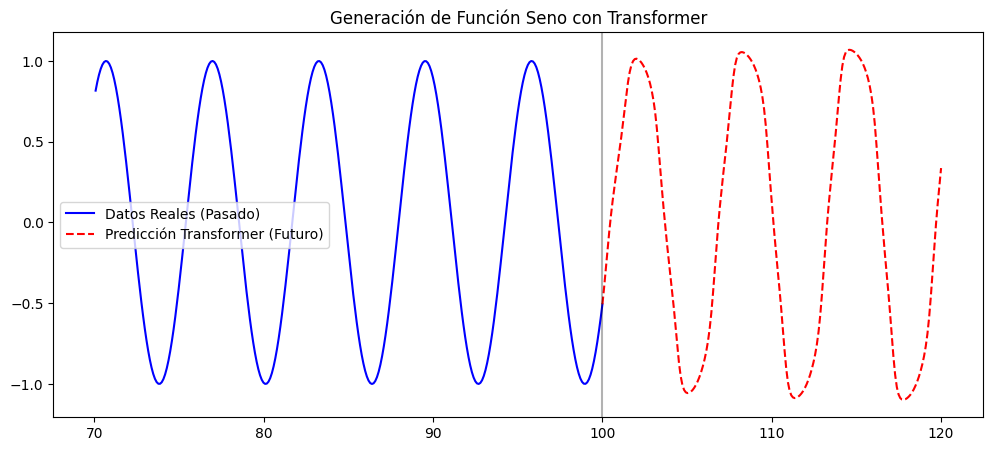

In [20]:
model.eval()
future_points = 200
predictions = []

# Tomamos la última ventana de los datos reales para empezar
last_sequence = X[-1].unsqueeze(0) 

for _ in range(future_points):
    with torch.no_grad():
        pred = model(last_sequence) # Predice el siguiente punto
        predictions.append(pred.item())
        
        # Actualizamos la ventana: desplazamos y añadimos la predicción
        new_row = pred.unsqueeze(1) 
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_row), dim=1)

# Pintar resultados
plt.figure(figsize=(12,5))
plt.plot(t[-300:], data[-300:], label="Datos Reales (Pasado)", color="blue")
plt.plot(np.linspace(t[-1], t[-1]+20, future_points), predictions, label="Predicción Transformer (Futuro)", linestyle="--", color="red")
plt.axvline(x=t[-1], color='black', alpha=0.3)
plt.legend()
plt.title("Generación de Función Seno con Transformer")
plt.show()

### 1.5 Métricas de Evaluación

Se calculan dos conjuntos de métricas:

1. **Predicción un paso** — el modelo predice `t+1` dado `[t-49…t]` sobre todo el conjunto de entrenamiento. Mide la calidad real del modelo.
2. **Predicción autorregresiva** — las 200 predicciones futuras se comparan con el seno analítico. Mide la degradación al encadenar predicciones.

| Métrica | Fórmula | Nota |
|---|---|---|
| MSE | $\frac{1}{N}\sum(\hat{y}-y)^2$ | |
| RMSE | $\sqrt{\text{MSE}}$ | Mismas unidades que la señal |
| MAE | $\frac{1}{N}\sum\|\hat{y}-y\|$ | Robusto a outliers |
| sMAPE | $\frac{100}{N}\sum\frac{2\|\hat{y}-y\|}{\|\hat{y}\|+\|y\|}$ | Versión simétrica del MAPE |
| R² | $1 - \frac{\sum(\hat{y}-y)^2}{\sum(\bar{y}-y)^2}$ | Varianza explicada (1 = perfecto) |

> **¿Por qué sMAPE y no MAPE?** El MAPE estándar $\frac{|\hat{y}-y|}{|y|}$ explota cuando el denominador $y \approx 0$. El seno cruza cero dos veces por ciclo, generando divisiones por valores cercanos a cero que inflan el MAPE artificialmente. El **sMAPE** usa $|\hat{y}|+|y|$ en el denominador, que nunca es cero salvo cuando ambos son exactamente cero simultáneamente.

> **Degradación autorregresiva esperada:** En la predicción de 200 pasos, R² y sMAPE empeorarán considerablemente respecto a la predicción un paso. Esto es **normal e inevitable**: cada predicción usa la salida anterior como entrada, acumulando el error. Para horizontes largos (>50 pasos), los modelos autorregresivos tienden a suavizar la señal y converger hacia la media de la señal. La métrica relevante del modelo es la **predicción un paso** (R² ≈ 0.997); la autorregresiva solo muestra cuánto resiste el modelo al error acumulado.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Métricas un paso (sobre todo el conjunto de entrenamiento) ──────────────
model.eval()
with torch.no_grad():
    train_preds = model(X).cpu().numpy()
y_np = y.cpu().numpy()

mse   = mean_squared_error(y_np, train_preds)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_np, train_preds)
# sMAPE: versión simétrica — evita explosión cuando sin(t) ≈ 0
smape = 100 * np.mean(2 * np.abs(y_np - train_preds) / (np.abs(y_np) + np.abs(train_preds) + 1e-8))
r2    = r2_score(y_np, train_preds)

print("=" * 50)
print("  Métricas — Seno (predicción un paso, N=950)")
print("=" * 50)
print(f"  MSE   : {mse:.6f}")
print(f"  RMSE  : {rmse:.6f}")
print(f"  MAE   : {mae:.6f}")
print(f"  sMAPE : {smape:.4f} %  (simétrico, robusto a cruces por cero)")
print(f"  R²    : {r2:.6f}")

# ── Métricas autorregresivas (200 pasos futuros vs seno real) ───────────────
t_future   = np.linspace(t[-1], t[-1] + 20, future_points)
sin_future = np.sin(t_future)
preds_arr  = np.array(predictions)

mse_ar   = mean_squared_error(sin_future, preds_arr)
rmse_ar  = np.sqrt(mse_ar)
mae_ar   = mean_absolute_error(sin_future, preds_arr)
smape_ar = 100 * np.mean(2 * np.abs(sin_future - preds_arr) / (np.abs(sin_future) + np.abs(preds_arr) + 1e-8))
r2_ar    = r2_score(sin_future, preds_arr)

print()
print("=" * 50)
print("  Métricas — Seno (autorregresivo, 200 pasos futuros)")
print("=" * 50)
print(f"  RMSE  : {rmse_ar:.6f}")
print(f"  MAE   : {mae_ar:.6f}")
print(f"  sMAPE : {smape_ar:.4f} %")
print(f"  R²    : {r2_ar:.6f}")
print()
print("  > Un R² cercano a 1 indica que el modelo captura")
print("    correctamente la periodicidad de la función seno.")

  Métricas — Seno (predicción un paso, N=950)
  MSE   : 0.000347
  RMSE  : 0.018625
  MAE   : 0.015577
  sMAPE : 4.8019 %  (simétrico, robusto a cruces por cero)
  R²    : 0.999307

  Métricas — Seno (autorregresivo, 200 pasos futuros)
  RMSE  : 0.186595
  MAE   : 0.141610
  sMAPE : 37.7297 %
  R²    : 0.926920

  > Un R² cercano a 1 indica que el modelo captura
    correctamente la periodicidad de la función seno.


---

## 2. Predicción de Acciones de Apple (AAPL)

Se aplica un Transformer a datos reales de bolsa descargados con **yfinance**. Los precios bursátiles presentan desafíos ausentes en el seno:

- **No estacionariedades** — la media y varianza cambian con el tiempo
- **Ruido** e impredecibilidad por eventos externos
- **Escala creciente** → normalización imprescindible

### Mejoras respecto a la versión básica

La versión inicial producía predicciones planas (R² ≈ −7) porque el modelo no tenía noción de orden temporal y convergía a predecir la media del entrenamiento. Se introducen cuatro mejoras:

| Mejora | Problema que resuelve |
|---|---|
| **Positional Encoding sinusoidal** | El Transformer no sabe qué token es "antes" o "después" sin esta información |
| **Sin data leakage en el scaler** | Ajustar el `MinMaxScaler` con datos de test es trampa: el modelo no debería ver el futuro durante el preprocesado |
| **`ReduceLROnPlateau` scheduler** | Si el modelo deja de mejorar, reduce la tasa de aprendizaje automáticamente en lugar de quedarse estancado |
| **Gradient clipping** | Evita actualizaciones de pesos catastróficas cuando los gradientes se disparan |

### 2.1 Datos y preprocesamiento

| Parámetro | Valor |
|---|---|
| Ticker | `AAPL` |
| Periodo | 2020-01-01 — 2026-01-01 |
| Feature | Precio de cierre (`Close`) |
| Normalización | `MinMaxScaler` ajustado **solo** con train → `[0, 1]` |
| `seq_length` | 60 días (contexto de 3 meses) |
| Split | 80 % train · 20 % test (temporal) |

> **Por qué ajustar el scaler solo con train:** Si se ajusta con todos los datos, el `max` y `min` del scaler incluyen valores del test set. El modelo se normalizaría conociendo precios futuros — una fuga de información que inflaría artificialmente las métricas.

In [22]:
%pip install --upgrade yfinance

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Descargar datos
df = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
data = df['Close'].values.reshape(-1, 1)

seq_length = 60

# ── Split temporal ANTES de normalizar (evitar data leakage) ─────────────────
split_idx  = int(len(data) * 0.8)
train_raw  = data[:split_idx]
# Para test necesitamos seq_length días de solapamiento para construir las primeras ventanas
test_raw   = data[split_idx - seq_length:]

# Scaler ajustado SOLO con datos de entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# Guardamos también el histórico completo escalado para visualización
data_scaled_full = scaler.transform(data)

# ── Ventanas deslizantes ──────────────────────────────────────────────────────
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i + seq_length])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)

X_train_np, y_train_np = create_sequences(train_scaled, seq_length)
X_test_np,  y_test_np  = create_sequences(test_scaled,  seq_length)

# Última ventana real (para arrancar la predicción autorregresiva futura)
last_window        = scaler.transform(data[-seq_length:])
last_window_tensor = torch.from_numpy(last_window).float().unsqueeze(0).to(device)

# ── Convertir a tensores ──────────────────────────────────────────────────────
X_train = torch.from_numpy(X_train_np).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
X_test  = torch.from_numpy(X_test_np).float().to(device)
y_test  = torch.from_numpy(y_test_np).float().to(device)

print(f"Total días      : {len(data)}")
print(f"Train           : {X_train.shape[0]} ventanas  (días 0 → {split_idx})")
print(f"Test            : {X_test.shape[0]}  ventanas  (días {split_idx} → {len(data)})")
print(f"Scaler rango    : [{scaler.data_min_[0]:.2f}, {scaler.data_max_[0]:.2f}] USD (solo train)")

[*********************100%***********************]  1 of 1 completed

Total días      : 1508
Train           : 1146 ventanas  (días 0 → 1206)
Test            : 302  ventanas  (días 1206 → 1508)
Scaler rango    : [54.21, 233.02] USD (solo train)


### 2.2 Arquitectura — `TimeSeriesTransformer` con Positional Encoding

#### ¿Por qué Positional Encoding?

El mecanismo de self-attention es **permutation-invariant**: si reordenamos los tokens de entrada, la salida es la misma (salvo en el orden). Para secuencias temporales esto es un problema grave — el modelo no sabría si el valor de ayer es anterior o posterior al de hoy.

El **Positional Encoding sinusoidal** (Vaswani et al., 2017) resuelve esto sumando a cada embedding un vector que depende únicamente de su posición:

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right) \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Cada posición obtiene un vector único. Las frecuencias altas distinguen posiciones contiguas; las bajas capturan relaciones a larga distancia.

#### Hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| `d_model` | 64 | Espacio de representación suficiente para capturar tendencias financieras |
| `nhead` | 4 | 4 cabezas × 16 dim/cabeza — varios "puntos de vista" sobre la secuencia |
| `num_layers` | 3 | Más profundidad para relaciones no lineales complejas |
| `dim_feedforward` | 256 | Red FFN 4× más ancha que `d_model` (convención estándar) |
| `dropout` | 0.1 | Regularización en attention + FFN |

#### Flujo completo

```
[batch, 60, 1]
   │
   ▼  Linear 1→64
[batch, 60, 64]
   │
   ▼  + PositionalEncoding
[batch, 60, 64]   ← cada token sabe su posición en la ventana
   │
   ▼  TransformerEncoder (3 capas)
[batch, 60, 64]
   │
   ▼  x[:, -1, :]   ← último token resume toda la secuencia
[batch, 64]
   │
   ▼  Linear 64→1
[batch, 1]         ← precio del día siguiente (normalizado)
```

In [23]:
# PositionalEncoding definida en sección 1 — reutilizada aquí con dropout=0.1

class TimeSeriesTransformer(nn.Module):
    """
    Transformer para predicción de series temporales financieras.

    Mejoras frente a SequenceTransformer (seno):
      - d_model=64 (vs 32): mayor capacidad de representación
      - num_layers=3 (vs 2): más profundidad para patrones no lineales
      - dim_feedforward=256: FFN interna 4× d_model (convención estándar)
      - dropout=0.1 en PE y capas: regularización para datos ruidosos
      - weight_decay en el optimizador: regularización L2 adicional
    """
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=3,
                 dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoding     = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):             # x: [batch, seq_len, input_size]
        x = self.input_projection(x)  # [batch, seq_len, d_model]
        x = self.pos_encoding(x)      # + codificación posicional sinusoidal
        x = self.transformer(x)       # [batch, seq_len, d_model]
        x = x[:, -1, :]              # último token [batch, d_model]
        return self.output_layer(x)   # [batch, 1]


model     = TimeSeriesTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)
print(f"\nParámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TimeSeriesTransformer(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros entrenables: 150,145


### 2.3 Entrenamiento — Mini-Batches + Early Stopping + Scheduler

Se incorporan tres técnicas de entrenamiento modernas:

#### Mini-Batch Training (`batch_size = 32`)
En lugar de pasar todo el conjunto de entrenamiento (1 146 muestras) de golpe en cada época, se divide en **mini-lotes de 32**. Esto produce ~35 actualizaciones de pesos por época en lugar de 1.

| | Batch completo | Mini-batch (32) |
|---|---|---|
| Actualizaciones/época | 1 | ~35 |
| Ruido estocástico | Ninguno | Beneficioso (escapa mínimos locales) |
| Generalización | Peor | Mejor |

El dataset se baraja (`shuffle=True`) en cada época para evitar que el modelo memorice el orden de los datos.

#### Early Stopping (`patience = 20`)
Detiene el entrenamiento cuando el **Test Loss no mejora** durante 20 épocas consecutivas. Esto resuelve dos problemas:

1. **Sobreajuste**: evita que el modelo siga ajustando el training set una vez que el test empeora
2. **Eficiencia**: no entrenar épocas innecesarias más allá del óptimo

Los **mejores pesos** (del epoch con menor Test Loss) se guardan en memoria y se restauran al finalizar — el modelo entregado siempre es el del mejor estado, no el del último epoch.

```
Epoch N  → nuevo mínimo test loss → guardar pesos, reiniciar contador
Epoch N+1..N+20 → sin mejora → contador++
Epoch N+21 → contador = 20 = patience → STOP → restaurar mejores pesos
```

#### `ReduceLROnPlateau` + Gradient Clipping
Se mantienen las técnicas de la versión anterior:
- LR se reduce ×0.5 si el test loss no mejora en 15 épocas
- `clip_grad_norm_` con `max_norm=1.0` evita gradientes explosivos

In [24]:
from torch.utils.data import DataLoader, TensorDataset

# ── Mini-batch DataLoader ─────────────────────────────────────────────────────
BATCH_SIZE    = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Mini-batches por época: {len(train_loader)}  ({BATCH_SIZE} muestras/batch)")

# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Para el entrenamiento si el test loss no mejora durante `patience` épocas.
    Guarda y restaura automáticamente los mejores pesos del modelo.

    Atributos:
        patience  : épocas sin mejora antes de parar
        min_delta : mejora mínima para considerar progreso real
        best_loss : mejor test loss visto hasta ahora
        counter   : épocas consecutivas sin mejora
        best_state: copia de los mejores pesos (state_dict)
    """
    def __init__(self, patience=20, min_delta=1e-6):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        """Devuelve True si hay que parar."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            # Copia profunda de los pesos — no referencia al modelo activo
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        """Carga los mejores pesos guardados de vuelta al modelo."""
        model.load_state_dict(self.best_state)

# ── Entrenamiento ─────────────────────────────────────────────────────────────
MAX_EPOCHS   = 300   # límite máximo — early stopping puede parar antes
scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=15, factor=0.5, min_lr=1e-6
)
early_stop   = EarlyStopping(patience=20)
train_losses = []
test_losses  = []
stopped_epoch = MAX_EPOCHS

for epoch in range(MAX_EPOCHS):
    # ── Mini-batch forward/backward ───────────────────────────────────────────
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss   = criterion(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    epoch_train_loss = np.mean(batch_losses)  # promedio sobre todos los mini-batches

    # ── Evaluación en test ────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    train_losses.append(epoch_train_loss)
    test_losses.append(test_loss)
    scheduler.step(test_loss)

    if (epoch + 1) % 25 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | Train: {epoch_train_loss:.6f} | "
              f"Test: {test_loss:.6f} | LR: {lr_now:.2e} | "
              f"Patience: {early_stop.counter}/{early_stop.patience}")

    # ── Comprobar early stopping ──────────────────────────────────────────────
    if early_stop.step(test_loss, model):
        stopped_epoch = epoch + 1
        print(f"\nEarly stopping en época {stopped_epoch} "
              f"(sin mejora en {early_stop.patience} épocas consecutivas)")
        break

# Restaurar los mejores pesos (no necesariamente los del último epoch)
early_stop.restore(model)
print(f"\nModelo restaurado al mejor estado:")
print(f"  Mejor Test Loss : {early_stop.best_loss:.6f}")
print(f"  Épocas totales  : {stopped_epoch} / {MAX_EPOCHS}")

Mini-batches por época: 36  (32 muestras/batch)
Epoch  25/300 | Train: 0.001348 | Test: 0.008085 | LR: 1.00e-03 | Patience: 5/20

Early stopping en época 39 (sin mejora en 20 épocas consecutivas)

Modelo restaurado al mejor estado:
  Mejor Test Loss : 0.001590
  Épocas totales  : 39 / 300


### 2.3.1 Curvas de Aprendizaje

Las curvas de aprendizaje permiten diagnosticar tres situaciones:

| Patrón | Diagnóstico |
|---|---|
| Train ↓ Test ↓ juntas | Convergencia correcta |
| Train ↓ Test ↑ (divergen) | **Sobreajuste** — el modelo memoriza train |
| Ambas altas y estables | **Infraajuste** — el modelo necesita más capacidad |

La línea vertical marca el punto donde el scheduler redujo por primera vez la tasa de aprendizaje.

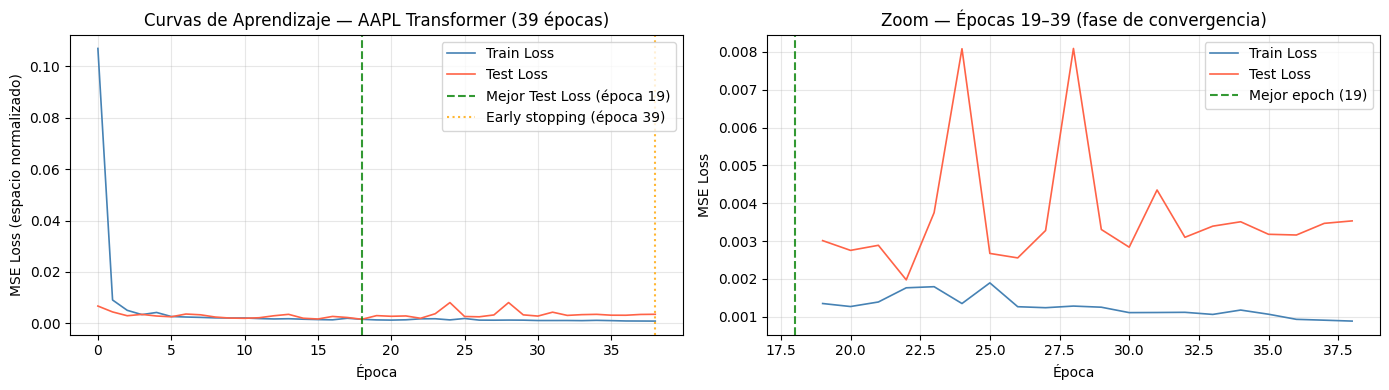

Mejor Test Loss : 0.001590  (época 19)
Train Loss final: 0.000884
Test  Loss final: 0.003533
Gap train/test de última época: +0.002649  (sobreajuste leve)


In [27]:
best_epoch  = int(np.argmin(test_losses))
n_epochs    = len(train_losses)
mid         = n_epochs // 2  # punto de corte para el zoom

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Curva completa ────────────────────────────────────────────────────────────
axes[0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=1.2)
axes[0].plot(test_losses,  label='Test Loss',  color='tomato',    linewidth=1.2)
axes[0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8,
                label=f'Mejor Test Loss (época {best_epoch+1})')
if stopped_epoch < MAX_EPOCHS:
    axes[0].axvline(x=stopped_epoch - 1, color='orange', linestyle=':', alpha=0.8,
                    label=f'Early stopping (época {stopped_epoch})')
axes[0].set_title(f'Curvas de Aprendizaje — AAPL Transformer ({n_epochs} épocas)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss (espacio normalizado)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Zoom segunda mitad (convergencia) ────────────────────────────────────────
axes[1].plot(range(mid, n_epochs), train_losses[mid:], label='Train Loss', color='steelblue', linewidth=1.2)
axes[1].plot(range(mid, n_epochs), test_losses[mid:],  label='Test Loss',  color='tomato',    linewidth=1.2)
axes[1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.8,
                label=f'Mejor epoch ({best_epoch+1})')
axes[1].set_title(f'Zoom — Épocas {mid}–{n_epochs} (fase de convergencia)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = test_losses[-1] - train_losses[-1]
print(f"Mejor Test Loss : {min(test_losses):.6f}  (época {best_epoch+1})")
print(f"Train Loss final: {train_losses[-1]:.6f}")
print(f"Test  Loss final: {test_losses[-1]:.6f}")
print(f"Gap train/test de última época: {gap:+.6f}  {'(sobreajuste leve)' if gap > 0.001 else '(sin sobreajuste significativo)'}")

### 2.4 Predicción Autorregresiva y Visualización

El modelo predice **50 días hábiles futuros** (~2.5 meses) de forma autorregresiva, igual que en la sección 1. Los pasos finales son:

1. Tomar la última ventana de 60 días conocidos
2. Predecir el día 61 → añadirlo a la ventana, eliminar el día más antiguo
3. Repetir 50 veces
4. **Desnormalizar** con `scaler.inverse_transform` → precios en USD
5. Graficar el histórico real + la predicción futura

> **Interpretación:** El modelo aprende la tendencia y la volatilidad del histórico, pero no puede anticipar eventos externos. La predicción representa la **continuación más probable** del patrón aprendido.

In [28]:
model.eval()
future_predictions = []
current_batch = last_window_tensor.clone()  # última ventana real conocida

for _ in range(50):
    with torch.no_grad():
        pred = model(current_batch)
        future_predictions.append(pred.item())
        new_pred      = pred.unsqueeze(1)  # [1, 1, 1]
        current_batch = torch.cat((current_batch[:, 1:, :], new_pred), dim=1)

# Desnormalizar a precios USD reales
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

print(f"Predicción generada: {len(future_predictions)} días futuros")
print(f"Rango predicho     : ${future_predictions.min():.2f} — ${future_predictions.max():.2f} USD")

Predicción generada: 50 días futuros
Rango predicho     : $238.82 — $263.64 USD


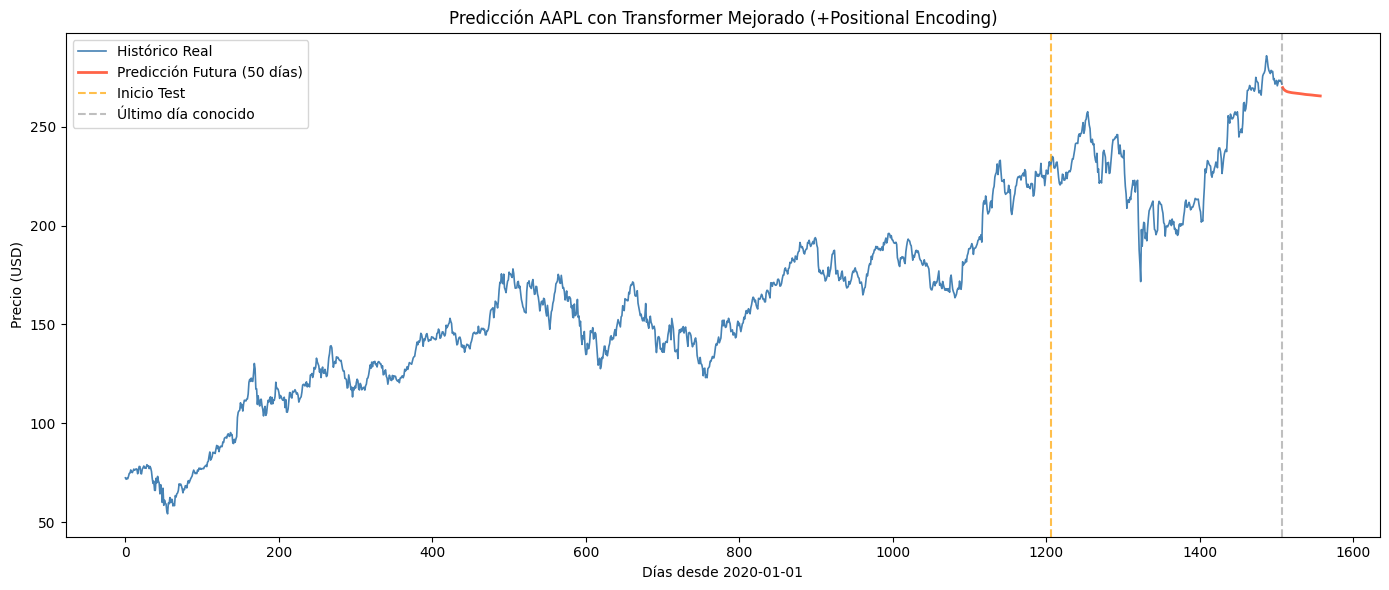

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(range(len(data)),
         scaler.inverse_transform(data_scaled_full),
         label='Histórico Real', color='steelblue', linewidth=1.2)
plt.plot(range(len(data), len(data) + 50),
         future_predictions,
         label='Predicción Futura (50 días)', color='tomato', linewidth=2)
plt.axvline(x=split_idx, color='orange', linestyle='--', alpha=0.7, label='Inicio Test')
plt.axvline(x=len(data) - 1, color='gray', linestyle='--', alpha=0.5, label='Último día conocido')
plt.title('Predicción AAPL con Transformer Mejorado (+Positional Encoding)')
plt.xlabel('Días desde 2020-01-01')
plt.ylabel('Precio (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 Métricas de Evaluación — Conjunto de Test

#### ¿Por qué las métricas están en dólares (USD)?

El modelo **nunca ve ni predice precios en dólares directamente**. Trabaja siempre en espacio normalizado `[0, 1]`. El paso a USD ocurre al final mediante la transformación inversa del `MinMaxScaler`.

**Transformación directa** (preprocesado — antes de entrenar):

$$x_{scaled} = \frac{x_{USD} - x_{min}}{x_{max} - x_{min}}$$

donde `x_min = $54.21` y `x_max = $233.02` son el mínimo y máximo del **conjunto de entrenamiento** (no de todos los datos — ver sección 2.1 sobre data leakage).

**Transformación inversa** (postprocesado — después de predecir):

$$x_{USD} = x_{scaled} \cdot (x_{max} - x_{min}) + x_{min}$$

Esto es exactamente lo que ejecuta `scaler.inverse_transform(...)`.

**Ejemplo concreto con valores reales del scaler:**

| Paso | Valor |
|---|---|
| Precio real | $200.00 USD |
| Normalizado | $(200 - 54.21)\ /\ (233.02 - 54.21) = 145.79\ /\ 178.81 = 0.815$ |
| Predicción del modelo | $0.801$ |
| Desnormalizado | $0.801 \times 178.81 + 54.21 = 197.4$ USD |
| Error absoluto (MAE) | $|200 - 197.4| = 2.6$ **USD** |

Por eso el **MAE y RMSE aparecen en dólares** — son errores calculados después de deshacer la normalización. El MAPE y R² son adimensionales y no dependen de la escala.

---

#### Sobre la Directional Accuracy

La **Directional Accuracy** mide si el modelo acierta la *dirección* del movimiento diario (sube o baja). Un valor cercano al 50 % **no indica que el modelo sea malo** — indica que el modelo está optimizado para predecir el *nivel* del precio (R² = 0.90), no para hacer trading direccional. En mercados financieros eficientes, predecir la dirección a corto plazo es estadísticamente equivalente a lanzar una moneda, independientemente de la calidad del regresor de nivel.

| Métrica | Descripción |
|---|---|
| RMSE (USD) | Error típico en dólares — raíz del error cuadrático medio |
| MAE (USD) | Error medio absoluto en dólares — robusto a outliers |
| MAPE (%) | Error relativo medio — independiente de la escala del precio |
| R² | Fracción de varianza del precio explicada por el modelo |
| Directional Accuracy (%) | Acierto en dirección del movimiento — ~50 % es lo esperado en un regresor de nivel |

Rango del scaler (solo train): min=$54.21  max=$233.02
Fórmula directa  : x_scaled = (x_USD - 54.21) / (233.02 - 54.21)
Fórmula inversa  : x_USD    = x_scaled × 178.80 + 54.21

  Métricas AAPL — Conjunto de Test (20 %)
  RMSE              : $7.13  ← error típico en USD
  MAE               : $5.57  ← error medio absoluto en USD
  MAPE              : 2.40 %  ← error relativo (sin escala)
  R²                : 0.9162   ← varianza explicada (1 = perfecto)
  Directional Acc.  : 50.17 %  ← acierto en dirección del movimiento

  Referencia: un clasificador aleatorio tendría ~50 % de Directional Acc.


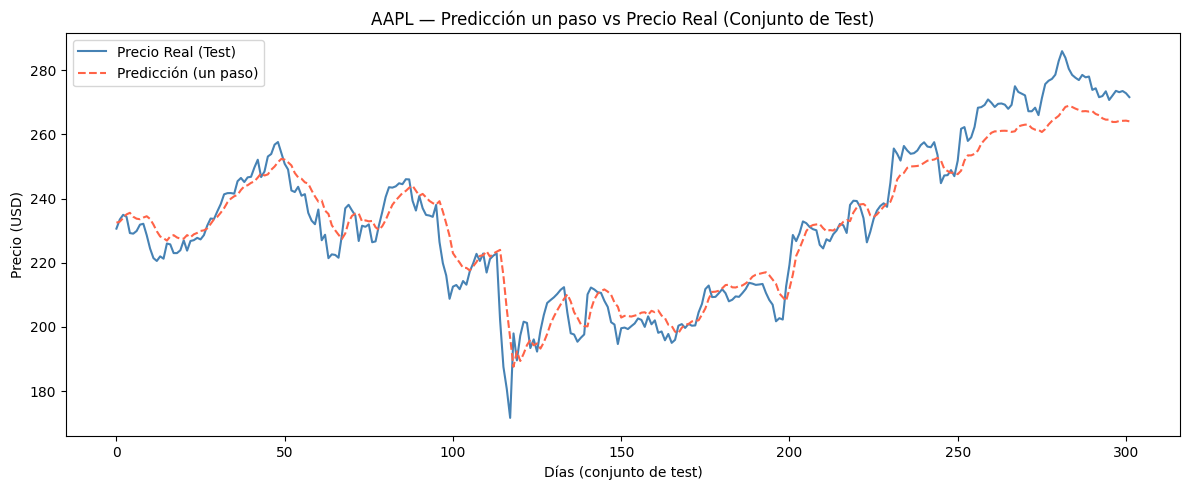

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Parámetros del scaler (ajustado solo con train) ───────────────────────────
x_min = scaler.data_min_[0]
x_max = scaler.data_max_[0]
print(f"Rango del scaler (solo train): min=${x_min:.2f}  max=${x_max:.2f}")
print(f"Fórmula directa  : x_scaled = (x_USD - {x_min:.2f}) / ({x_max:.2f} - {x_min:.2f})")
print(f"Fórmula inversa  : x_USD    = x_scaled × {x_max - x_min:.2f} + {x_min:.2f}")
print()

# ── Predicciones sobre el conjunto de test ────────────────────────────────────
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test).cpu().numpy()
y_test_np_orig = y_test.cpu().numpy()

# Desnormalizar — aquí es donde los números pasan de [0,1] a USD
test_preds_usd = scaler.inverse_transform(test_preds_scaled)
y_test_usd     = scaler.inverse_transform(y_test_np_orig)

# ── Métricas en espacio original (USD) ────────────────────────────────────────
mse  = mean_squared_error(y_test_usd, test_preds_usd)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_usd, test_preds_usd)
mape = np.mean(np.abs((y_test_usd - test_preds_usd) / (np.abs(y_test_usd) + 1e-8))) * 100
r2   = r2_score(y_test_usd, test_preds_usd)

# ── Directional Accuracy ──────────────────────────────────────────────────────
dir_real = np.sign(np.diff(y_test_usd.flatten()))
dir_pred = np.sign(np.diff(test_preds_usd.flatten()))
dir_acc  = np.mean(dir_real == dir_pred) * 100

print("=" * 50)
print("  Métricas AAPL — Conjunto de Test (20 %)")
print("=" * 50)
print(f"  RMSE              : ${rmse:.2f}  ← error típico en USD")
print(f"  MAE               : ${mae:.2f}  ← error medio absoluto en USD")
print(f"  MAPE              : {mape:.2f} %  ← error relativo (sin escala)")
print(f"  R²                : {r2:.4f}   ← varianza explicada (1 = perfecto)")
print(f"  Directional Acc.  : {dir_acc:.2f} %  ← acierto en dirección del movimiento")
print()
print("  Referencia: un clasificador aleatorio tendría ~50 % de Directional Acc.")

# ── Visualización: predicciones vs valores reales en el test set ──────────────
plt.figure(figsize=(12, 5))
plt.plot(y_test_usd,     label='Precio Real (Test)',   color='steelblue')
plt.plot(test_preds_usd, label='Predicción (un paso)', color='tomato', linestyle='--')
plt.title('AAPL — Predicción un paso vs Precio Real (Conjunto de Test)')
plt.xlabel('Días (conjunto de test)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.tight_layout()
plt.show()